## Vertical cross-section to show zonal moisture flux `xarray` and `matplotlib` (Use environment `NPL 2025b`)

This notebook shows how to do a vertical cross-section from any MPAS mesh. Make sure you use the environment `NPL 2025b`


In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from scipy.interpolate import LinearNDInterpolator
import glob

Function for quick vertical interpolation from model levels to pressure levels.

In [2]:
def interp_vertical(var_line,pres_line,target_p):
    """Interpolates 2D line data vertically onto standard pressure levels."""
    n_pts = var_line.shape[0]
    n_p = len(target_p)
    result = np.zeros((n_p,n_pts))
    
    for i in range(n_pts):
        # Reverse profiles so pressure increases
        p_prof = pres_line[i,::-1]
        v_prof = var_line[i,::-1]
        # Log-linear pressure interpolation
        result[:,i] = np.interp(np.log(target_p[::-1]),np.log(p_prof),v_prof)[::-1]
        
    return result

Set base path and read in history file and static file.

In [3]:
base_path = "../240-48km_variable/"
static_path = f"{base_path}SouthAmerica.static.nc"
data_path = f"{base_path}history.2014-09-13_00.00.00.nc"

ds_stat = xr.open_dataset(static_path,decode_times=False).squeeze()
ds_data = xr.open_dataset(data_path).squeeze()

Here we define our zonal cross-section line cutting across S America at 31 S. We can also choose to plot U and W with windbarbs or quivers.

In [4]:
# Define cross-section line
lat_start, lon_start = -31.0, 285.0
lat_end, lon_end = -31.0, 315.0
wind = "quiver" # Can be barb or quiver
n_pt = 500  # Number of points along the line

# Pressure levels to interpolate to
p_1d = np.arange(1000,50,-25)
n_p = len(p_1d)

Reading in the 3D variables we care about. qv, and winds.

In [5]:
qv = ds_data["qv"].values
uwind = ds_data["uReconstructZonal"].values
vwind = ds_data["uReconstructMeridional"].values

# Destagger vertical velocity to cell centers
wwind_raw = ds_data["w"].values
w_scale = 150
wwind = 0.5 * (wwind_raw[:, :-1] + wwind_raw[:, 1:]) * w_scale

#calculate moisture flux
#wind_speed = np.sqrt(uwind**2+vwind**2)
#mflux = qv*wind_speed
mflux = qv*uwind #for zonal flux

pres = ds_data["pressure"].values * 0.01  # Convert Pa to hPa

Create 500 (or whatever `n_pt` is) evenly spaced points along the cross-section. It then uses MPAS cell centers to construct a 2D Delauney triangulation to spatially interpolate along the line.

In [6]:
lon_1d = np.linspace(lon_start, lon_end, n_pt)
lat_1d = np.linspace(lat_start, lat_end, n_pt)
line_points = np.column_stack((lon_1d, lat_1d))  # (500, 2)

# MPAS grid triangulation
mpas_lons = np.degrees(ds_stat["lonCell"].values)
mpas_lats = np.degrees(ds_stat["latCell"].values)
tri = Delaunay(np.column_stack((mpas_lons, mpas_lats)))

Here, we interpolate our 3D model-level data from the unstructured MPAS mesh onto the cross-section path. It then vertically interpolates to pressure levels using the `interp_vertical` function we created at the top.

In [7]:
# Interpolate winds and mflux
n_levels = pres.shape[1]

pres_line  = np.zeros((n_pt,n_levels))
mflux_line = np.zeros((n_pt,n_levels))
uwind_line = np.zeros((n_pt,n_levels))
vwind_line = np.zeros((n_pt,n_levels))
wwind_line = np.zeros((n_pt,n_levels))

for k in range(n_levels):
    pres_line[:,k]  = LinearNDInterpolator(tri,pres[:,k])(line_points)
    mflux_line[:,k] = LinearNDInterpolator(tri,mflux[:,k])(line_points)
    uwind_line[:,k] = LinearNDInterpolator(tri,uwind[:,k])(line_points)
    vwind_line[:,k] = LinearNDInterpolator(tri,vwind[:,k])(line_points)
    wwind_line[:,k] = LinearNDInterpolator(tri,wwind[:,k])(line_points)

hh_cross_section = interp_vertical(mflux_line,pres_line,p_1d)
uu_cross_section = interp_vertical(uwind_line,pres_line,p_1d)
vv_cross_section = interp_vertical(vwind_line,pres_line,p_1d)
ww_cross_section = interp_vertical(wwind_line,pres_line,p_1d)

Now, interpolate terrain along that line and interpolate to pressure level so we can see the mountains.

In [8]:
# Terrain/pressure interpolation needed to plot terrain
ter = ds_stat["ter"].squeeze().values
terrain_line = LinearNDInterpolator(tri,ter)(line_points)
terrain_pressure = 1000*np.exp(-9.81*terrain_line/(287.0*280.0))

Finally, we make the plot. This is all fairly basic matplotlib contours and barbs/quivers with a log scale on the Y-axis.

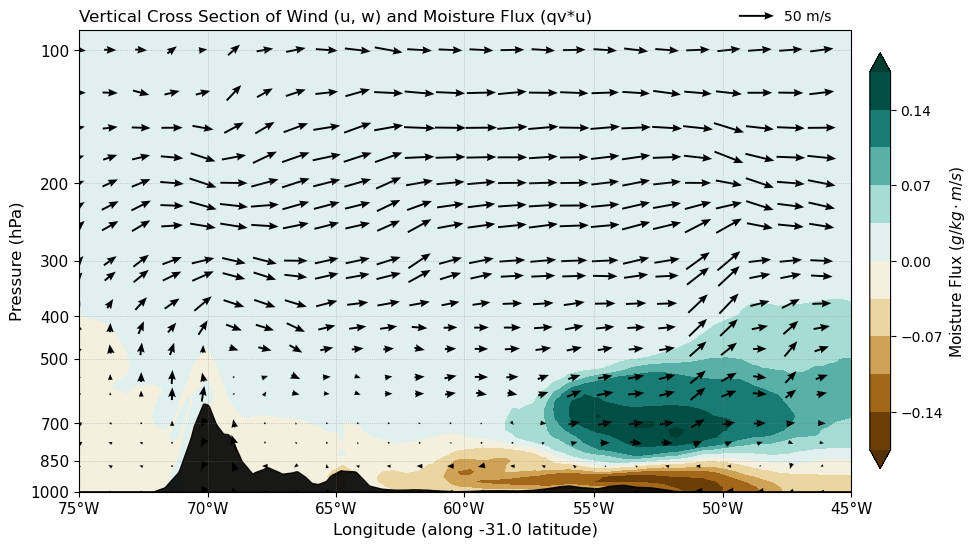

In [9]:
fig, ax = plt.subplots(figsize=(12,6))

# Make mflux contour plot
vmax = np.nanmax(np.abs(hh_cross_section))
levels = np.round(np.linspace(-vmax,vmax,11),2)
t_cs = ax.contourf(np.arange(n_pt),p_1d,hh_cross_section,cmap="BrBG",levels=levels,extend="both")
cbar = plt.colorbar(t_cs,ax=ax,shrink=0.9,pad=0.02)
cbar.set_label("Moisture Flux ($g/kg \cdot m/s$)",fontsize=11)

# Make wind plot
# Subsample vertical levels on a log-scale so arrows/barbs don't crowd
log_p_levels = np.linspace(np.log10(p_1d.min()),np.log10(p_1d.max()),22)
selected_indices = sorted(set([np.abs(p_1d-10**p).argmin() for p in log_p_levels]))
X, Y = np.meshgrid(np.arange(n_pt),p_1d)
if wind=="quiver":
    sub_y = selected_indices
    sub_x = slice(None,None,20)
    Q = ax.quiver(X[sub_y,sub_x],Y[sub_y,sub_x],uu_cross_section[sub_y,sub_x],ww_cross_section[sub_y,sub_x],
                  scale=1100,width=0.0025,headwidth=4,color="black",pivot="mid")
    ax.quiverkey(Q,X=0.90,Y=1.03,U=50,label="50 m/s",labelpos="E")
elif wind=="barb":
    ax.barbs(X[selected_indices,::30],Y[selected_indices,::30],uu_cross_section[selected_indices,::30],
             ww_cross_section[selected_indices,::30],length=5,linewidth=0.5,barbcolor="black",pivot="middle")

# Plot terrain as a fill
ax.fill_between(np.arange(n_pt),p_1d.max(),terrain_pressure,color="black",alpha=0.9)

# Label lons
lon_1d_180 = np.where(lon_1d>180,lon_1d-360,lon_1d)
target_lons = np.arange(np.ceil(lon_1d_180.min()/5)*5,lon_1d_180.max()+0.01,5)
ax.set_xticks([np.abs(lon_1d_180 - l).argmin() for l in target_lons])
ax.set_xticklabels([f"{abs(int(l))}°W" for l in target_lons], fontsize=11)
ax.set_xlabel(f"Longitude (along {lat_start} latitude)",fontsize=12)

# Format Y-axis and add labels
ax.set_yscale("log")
ax.set_ylim(1000,90)
ax.set_yticks(ticks := [1000, 850, 700, 500, 400, 300, 200, 100],labels=ticks,fontsize=11)
ax.tick_params(axis="y", which="minor", left=False, right=False)
ax.set_ylabel("Pressure (hPa)",fontsize=12)
ax.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.6)

# Title and save fig
plt.title("Vertical Cross Section of Wind (u, w) and Moisture Flux (qv*u)",loc="left",fontsize=12)
#plt.savefig("xsec_mflux.jpg", bbox_inches="tight", dpi=300)
plt.show()